# Robust Online Inertia Estimation Method
Adapted from Liu et al. "On-Line Inertia Estimation for Synchronous and Non-Synchronous Devices", specifically their E2 method, which takes into account the controller's damping and primary frequency control. This helps to remove oscillations in their estimated inertia. 

In [1]:
%matplotlib inline

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [2]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"

case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")
STEP_TIME = 0.01 # 10 ms

## Load in case file and, run power flow and TDS

In [3]:
ss = andes.load(case_path, setup=False)
ss.REGF2.set("Tr",1,0.005)
#ss.REGF2.set("KPi",1,1)
#ss.REGF2.set("KPv",1,6)


print(ss.REGF2.Tr.v)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 20 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

[0.005]


True

In [4]:
# get frequency, RoCoF, and power time-series. 
tds_df = pd.concat([ss.TDS.get_timeseries(ss.BusROCOF.f), 
                    ss.TDS.get_timeseries(ss.BusROCOF.Wf_y), 
                    ss.TDS.get_timeseries(ss.REGF2.Pe)],
                    axis=1)

tds_df.columns = ["f", "df/dt", "p"]

tds_df

,f,df/dt,p
0.000000,1.000000,0.000000,0.200000
0.000100,1.000000,0.000000,0.200000
0.010100,1.000000,0.000000,0.200000
0.020100,1.000000,0.000000,0.200000
0.030100,1.000000,0.000000,0.200000
...,...,...,...
19.976867,0.986720,0.000030,0.428784
19.986867,0.986721,0.000034,0.428758
19.996867,0.986722,0.000038,0.428732
19.999900,0.986722,0.000039,0.428723


## Inertia Calculation

In [91]:
t0 = 0
tf = 20

#TM = 0.104
TM = 0.001

TD = 10e-4

eps_x = 10e-5
eps_w = 10e-5

In [101]:
# calculate RoCoF, derivative of RoCoF (RoRoCOF?? lol), and derivative of power (RoCoP)
# need to interpolate between values b/c continuous-- called by solver

domega_dt = CubicSpline(tds_df.index, tds_df.loc[:,"df/dt"])      
d2omega_dt2 = domega_dt.derivative()               
dp_dt = CubicSpline(tds_df.index, tds_df.loc[:,"p"]).derivative()

In [102]:
def gamma(x, eps):
    return np.where(x >= eps, -1.0, np.where(x <= -eps, 1.0, 0.0))

In [112]:
def rhs(t, y, TM, TD, eps_x, eps_w):
    Mstar, Dstar, domega_int, dp_int = y

    dp = dp_dt(t)
    d2w = d2omega_dt2(t)
    dw = domega_dt(t)

    dMstar = gamma(d2w, eps_x) * (dp - Mstar*d2w - Dstar*dw) / TM
    dDstar = gamma(domega_int, eps_w) * (dp_int - Mstar*dw - Dstar*domega_int) / TD
    ddomega_int = dw     
    ddp_int = dp  

    #plt.scatter(t, dp - Mstar*d2w - Dstar*dw, color="blue", s=1) # 's' controls the size
 
    return [dMstar, dDstar, ddomega_int, ddp_int]

In [113]:
sol = solve_ivp(rhs, [t0, tf], y0=[0, 0, 0, 0],
                 args=(TM, TD, eps_x, eps_w),
                 method='Radau', dense_output=True,
                 t_eval=tds_df.index)

#plt.show()


(5.0, 6.0)

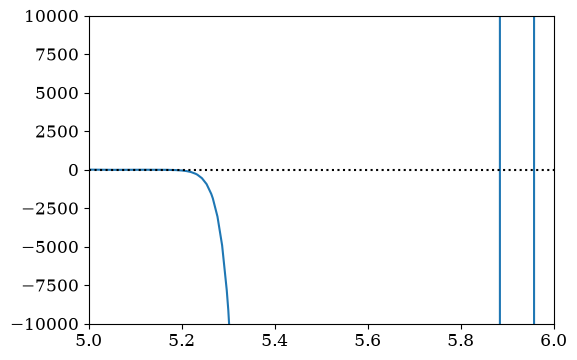

In [118]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol.t, sol.y[0])
ax.axline((0, 5), slope=0, color="black", linestyle=":")
ax.set_ylim(-10000, 10000)
ax.set_xlim(5, 6)

In [32]:
vals_df = pd.DataFrame(sol.y[:2]).T
vals_df.index = sol.t
vals_df.columns = ["M", "D"]
#vals_df

m_s = vals_df.loc[:,"M"]
m_s

0.000000      0.000000e+00
0.000100      0.000000e+00
0.010100      0.000000e+00
0.020100      0.000000e+00
0.030100      0.000000e+00
                 ...      
19.976867    3.261559e+188
19.986867    1.176832e+189
19.996867    2.257716e+189
19.999900    2.638176e+189
20.000000    2.651168e+189
Name: M, Length: 3603, dtype: float64

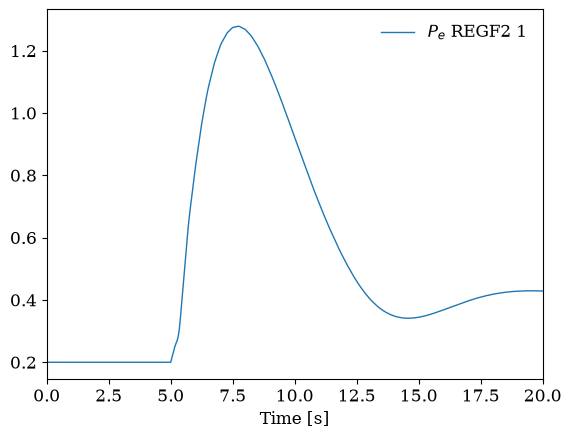

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [104]:
ss.TDS.plot(ss.REGF2.Pe)

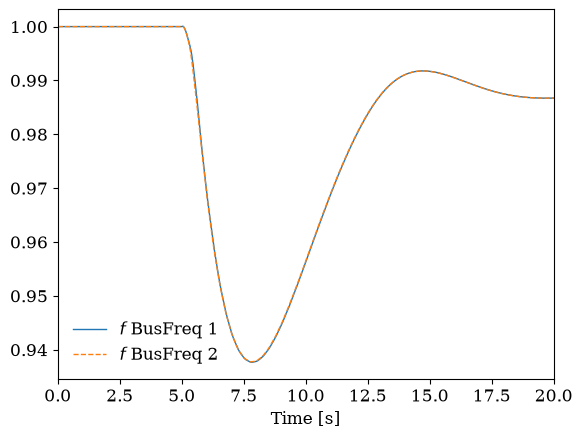

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [105]:
ss.TDS.plot(ss.BusFreq.f)

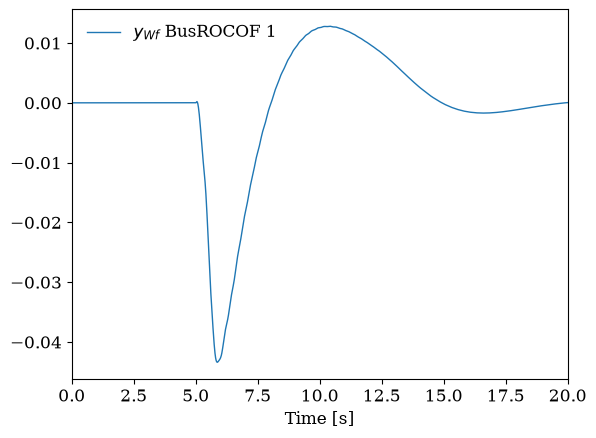

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [106]:
ss.TDS.plot(ss.BusROCOF.Wf_y)

In [ ]:
ss.TDS.plot(ss.Bus.v)

# Test Simple Inertia Calculation

In [5]:
from algebraic_inertia_estimation import calc_inertia_algebraic

In [41]:
m = calc_inertia_algebraic(tds_df, 0.2, t0=5.0, tf=6)

(5.1, 6.0)

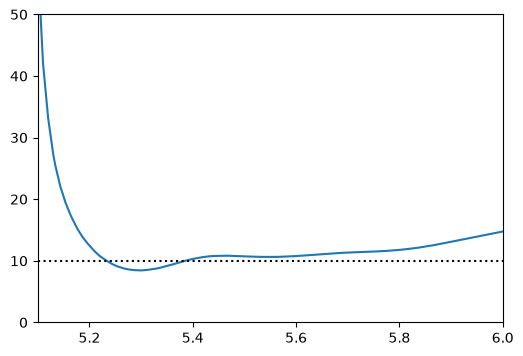

In [42]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(m.index,  m)
ax.axline((0, 10), slope=0, color="black", linestyle=":")
ax.set_ylim(0, 50)
ax.set_xlim(5.1, 6)

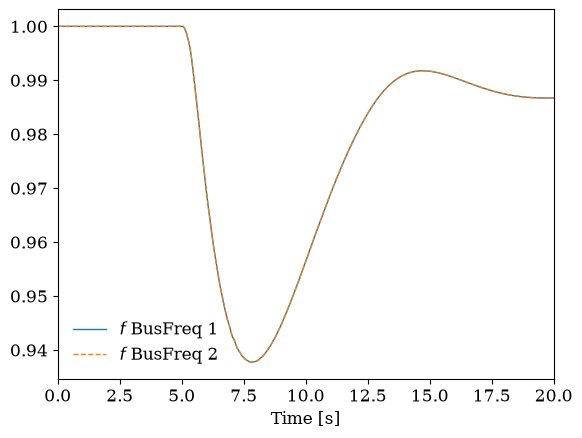

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [26]:
ss.TDS.plot(ss.BusFreq.f)